In [40]:
# libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy import stats

# **1-2. Simple EDA + Data Preparation**
- Performed the data preparation first as the horsepower column needs to be fixed before we can graph

In [41]:
pd.read_csv('https://archive.ics.uci.edu/ml/machinelearning-databases/auto-mpg/auto-mpg.data', delim_whitespace=True, header=None) # did not work

TypeError: read_csv() got an unexpected keyword argument 'delim_whitespace'

In [42]:
pd.read_csv('https://archive.ics.uci.edu/ml/machinelearning-databases/auto-mpg/auto-mpg.data', header=None) # did not work

HTTPError: HTTP Error 404: Not Found

In [43]:
df = pd.read_csv("auto-mpg.csv") # downloaded the dataset through kaggle instead

In [44]:
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino


In [45]:
df.describe()

,mpg,cylinders,displacement,weight,acceleration,model year,origin
count,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000
mean,23.514573,5.454774,193.425879,2970.424623,15.568090,76.010050,1.572864
std,7.815984,1.701004,104.269838,846.841774,2.757689,3.697627,0.802055
min,9.000000,3.000000,68.000000,1613.000000,8.000000,70.000000,1.000000
25%,17.500000,4.000000,104.250000,2223.750000,13.825000,73.000000,1.000000
50%,23.000000,4.000000,148.500000,2803.500000,15.500000,76.000000,1.000000
75%,29.000000,8.000000,262.000000,3608.000000,17.175000,79.000000,2.000000
max,46.600000,8.000000,455.000000,5140.000000,24.800000,82.000000,3.000000


In [46]:
print(df.dtypes)
print(f"\nShape of dataset: {df.shape}")
print(f"Number of '?' values: {(df['horsepower'] == '?').sum()}")

mpg             float64
cylinders         int64
displacement    float64
horsepower          str
weight            int64
acceleration    float64
model year        int64
origin            int64
car name            str
dtype: object

Shape of dataset: (398, 9)
Number of '?' values: 6


In [47]:
df.replace('?', np.nan, inplace=True)
df.isna().sum()
df['horsepower'] = pd.to_numeric(df['horsepower'])
df.fillna(df['horsepower'].mean(), inplace=True)

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
0,18.0,8,307.0,130.0,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,1,ford torino
...,...,...,...,...,...,...,...,...,...
393,27.0,4,140.0,86.0,2790,15.6,82,1,ford mustang gl
394,44.0,4,97.0,52.0,2130,24.6,82,2,vw pickup
395,32.0,4,135.0,84.0,2295,11.6,82,1,dodge rampage
396,28.0,4,120.0,79.0,2625,18.6,82,1,ford ranger


In [48]:
df.describe()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin
count,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000
mean,23.514573,5.454774,193.425879,104.469388,2970.424623,15.568090,76.010050,1.572864
std,7.815984,1.701004,104.269838,38.199187,846.841774,2.757689,3.697627,0.802055
min,9.000000,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000,1.000000
25%,17.500000,4.000000,104.250000,76.000000,2223.750000,13.825000,73.000000,1.000000
50%,23.000000,4.000000,148.500000,95.000000,2803.500000,15.500000,76.000000,1.000000
75%,29.000000,8.000000,262.000000,125.000000,3608.000000,17.175000,79.000000,2.000000
max,46.600000,8.000000,455.000000,230.000000,5140.000000,24.800000,82.000000,3.000000


In [49]:
df.drop(columns=['car name'], inplace=True)

In [50]:
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin
0,18.0,8,307.0,130.0,3504,12.0,70,1
1,15.0,8,350.0,165.0,3693,11.5,70,1
2,18.0,8,318.0,150.0,3436,11.0,70,1
3,16.0,8,304.0,150.0,3433,12.0,70,1
4,17.0,8,302.0,140.0,3449,10.5,70,1


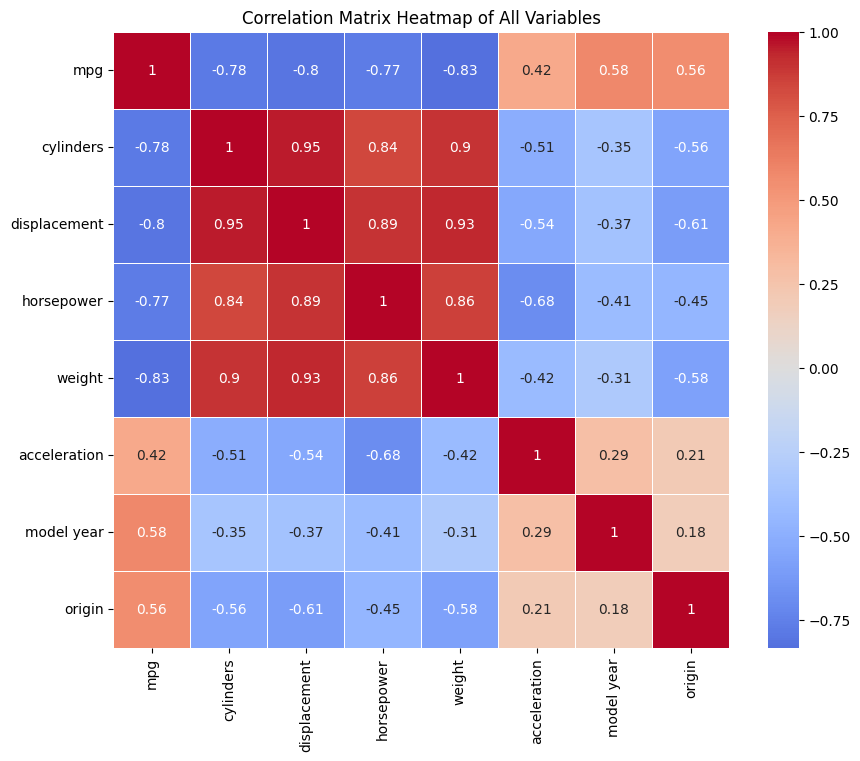

In [51]:
correlation_matrix = df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, square=True, linewidths=0.5)
plt.title('Correlation Matrix Heatmap of All Variables')
plt.show()

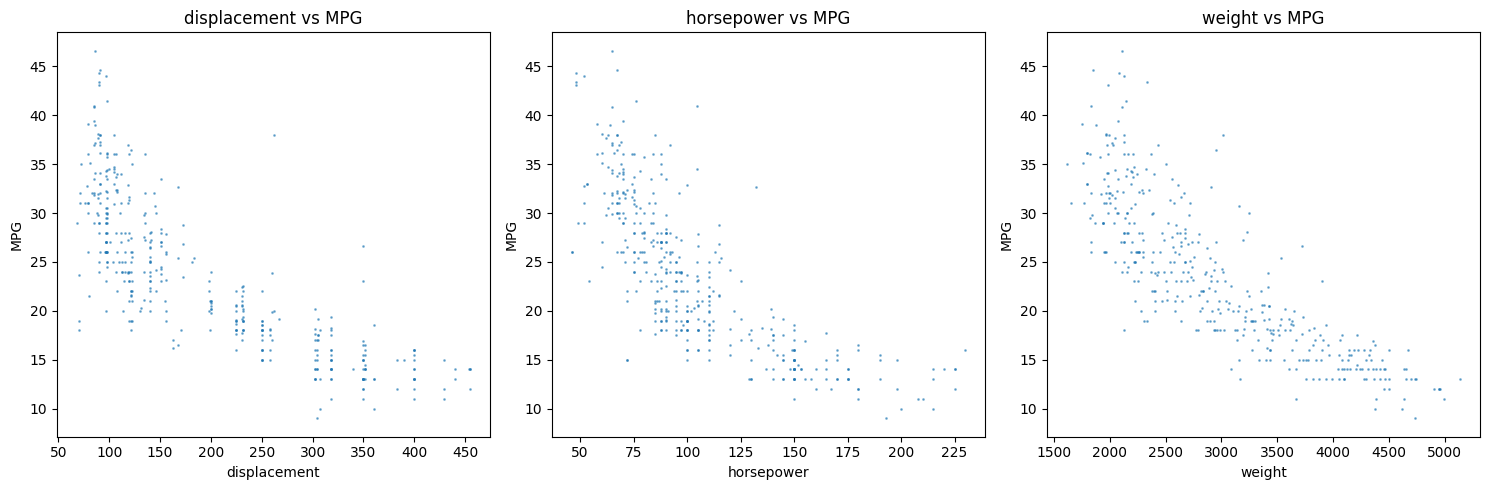

In [52]:
predictor_columns = df.columns[2:5]
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, column in enumerate(predictor_columns):
    axes[i].scatter(df[column], df['mpg'], alpha=0.5, s=1)
    axes[i].set_xlabel(column)
    axes[i].set_ylabel('MPG')
    axes[i].set_title(f'{column} vs MPG')

plt.tight_layout()
plt.show()

In [53]:
X = df.drop('mpg', axis=1)
y = df['mpg']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True)

print(f"Training set size: {len(X_train):,} observations ({len(X_train)/len(X)*100:.1f}%)")
print(f"Test set size: {len(X_test):,} observations ({len(X_test)/len(X)*100:.1f}%)")
print(f"Total observations: {len(X):,}")

Training set size: 318 observations (79.9%)
Test set size: 80 observations (20.1%)
Total observations: 398


# **3. Build Original Model**
- Create the model and check its summary results

In [54]:
X_train_const = sm.add_constant(X_train)
X_test_const = sm.add_constant(X_test)

model = sm.OLS(y_train, X_train_const)
results = model.fit()

In [55]:
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.814
Model:                            OLS   Adj. R-squared:                  0.810
Method:                 Least Squares   F-statistic:                     193.8
Date:                Tue, 27 Jan 2026   Prob (F-statistic):          3.43e-109
Time:                        15:02:51   Log-Likelihood:                -841.81
No. Observations:                 318   AIC:                             1700.
Df Residuals:                     310   BIC:                             1730.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const          -20.7822      5.477     -3.794   

In [56]:
print(f"R squared score: {results.rsquared}")

R squared score: 0.8139541213831769


# **4. Calculate VIF**
- Calculate its Variance Inflation Factors and remove the variables with VIF > 5 and p > 0.05

In [57]:
vif_data = pd.DataFrame()
vif_data["Variable"] = X_train.columns
vif_data["VIF"] = [variance_inflation_factor(X_train.values, i) for i in range(X_train.shape[1])]

print("Variance Inflation Factors (VIF):")
print(vif_data.round(3))

Variance Inflation Factors (VIF):
       Variable      VIF
0     cylinders  120.657
1  displacement   96.515
2    horsepower   61.167
3        weight  132.420
4  acceleration   66.679
5    model year  112.639
6        origin    8.645


# **5. Remove Unnecessary Variables**
- Create the adjusted model and tried the results and VIF again

In [58]:
new_df = df[['mpg','weight', 'model year', 'origin']]
new_df

,mpg,weight,model year,origin
0,18.0,3504,70,1
1,15.0,3693,70,1
2,18.0,3436,70,1
3,16.0,3433,70,1
4,17.0,3449,70,1
...,...,...,...,...
393,27.0,2790,82,1
394,44.0,2130,82,2
395,32.0,2295,82,1
396,28.0,2625,82,1


In [59]:
X = new_df.drop('mpg', axis=1)
y = new_df['mpg']

X_train2, X_test2, y_train2, y_test2 = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True)

print(f"Training set size: {len(X_train2):,} observations ({len(X_train2)/len(X)*100:.1f}%)")
print(f"Test set size: {len(X_test2):,} observations ({len(X_test2)/len(X)*100:.1f}%)")
print(f"Total observations: {len(X):,}")

Training set size: 318 observations (79.9%)
Test set size: 80 observations (20.1%)
Total observations: 398


In [71]:
X_train_const2 = sm.add_constant(X_train2)
X_test_const2 = sm.add_constant(X_test2)

model2 = sm.OLS(y_train2, X_train_const2)
results2 = model2.fit()

In [72]:
print(results2.summary())

                            OLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.812
Model:                            OLS   Adj. R-squared:                  0.810
Method:                 Least Squares   F-statistic:                     450.7
Date:                Tue, 27 Jan 2026   Prob (F-statistic):          2.09e-113
Time:                        15:11:34   Log-Likelihood:                -843.87
No. Observations:                 318   AIC:                             1696.
Df Residuals:                     314   BIC:                             1711.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        -20.4460      4.685     -4.364      0.0

In [73]:
vif_data = pd.DataFrame()
vif_data["Variable"] = X_train2.columns
vif_data["VIF"] = [variance_inflation_factor(X_train2.values, i) for i in range(X_train2.shape[1])]

print("Variance Inflation Factors (VIF):")
print(vif_data.round(3))

Variance Inflation Factors (VIF):
     Variable     VIF
0      weight  17.038
1  model year  32.644
2      origin   7.132


# **6. Compare R^2 Values**
- The R^2 and adjusted R^2 value of the original model are 0.814 and 0.810 respectively.
- The R^2 and adjusted R^2 value of the adjusted model are 0.812 and 0.810 respectively.

Comparing Results:
- Original model has a better R^2 value
- Both models are equal in adjusted R^2 value
- Adjusted model has a better F-Statistic with 450.7 compared to 193.8 (this tells the significance of the model)
- Adjusted model has a better prob (F-Statistic) with 2.09e-113 compared to 3.43e-109 (this tells the significance of the model in p-values)
- Adjusted model has a better log-likelihood with -843.87 compared to -841.81 (this tells which better fits the data)
- Adjusted model has a better AIC with 1696 compared to 1700 (is the extra complexity worth it)
- Adjusted model has a better BIC with 1711 compared to 1730 (better AIC)

Overall, the results show that the adjusted model is better than the original model because of the better yielded output. It fits the data better, it is more significant (not random), and the complexity is worth the outcome.

# **7. Compare Error Metric**

In [78]:
def calculate_metrics(y_true, y_pred):
    """Calculate comprehensive regression performance metrics"""
    mse = np.mean((y_true - y_pred) ** 2)
    rmse = np.sqrt(mse)
    mae = np.mean(np.abs(y_true - y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    
    return {
        'RMSE': rmse,
        'MAE': mae, 
        'MAPE': mape,
    }

y_pred_test = results.predict(X_test_const)
train_metrics = calculate_metrics(y_test, y_pred_test)
y_pred_test2 = results2.predict(X_test_const2)
train_metrics2 = calculate_metrics(y_test2, y_pred_test2)

print("TEST SET PERFORMANCE (Original Model)")
print("="*45)
for metric, value in train_metrics.items():
    if metric in ['RMSE', 'MAE']:
        print(f"{metric:<8}: {value:.4f}")
    elif metric == 'MAPE':
        print(f"{metric:<8}: {value:.2f}%")
    else:
        print(f"{metric:<8}: {value:.4f}")

print("TEST SET PERFORMANCE (Adjusted Model)")
print("="*45)
for metric, value in train_metrics2.items():
    if metric in ['RMSE', 'MAE']:
        print(f"{metric:<8}: {value:.4f}")
    elif metric == 'MAPE':
        print(f"{metric:<8}: {value:.2f}%")
    else:
        print(f"{metric:<8}: {value:.4f}")

TEST SET PERFORMANCE (Original Model)
RMSE    : 2.8628
MAE     : 2.2534
MAPE    : 11.43%
TEST SET PERFORMANCE (Adjusted Model)
RMSE    : 2.9247
MAE     : 2.2495
MAPE    : 11.31%


The adjusted model performs slightly better than the original model on unseen data. The adjusted model has a lower MAE and MAPE scores meaning their predictions are slightly better compared to the original model (committing less errors).

# **8. Interpret Beta Coefficients**

Final Model Coefficients:
- constant: -20.4460
- weight: -0.0061 (heavier cars get worse MPG)
- model year: 0.7953 (newer cars get better MPG)
- origin: 1.0814 (where the car is made gets better MPG)

A 1-unit change the weight, model year, and origin changes the MPG by -0.0061, 0.7953, 1.0814 respectively.

Model year has the strongest impact because it has the highest t-statistic (14.00) compared to the other variables weight(-20.82) and origin (3.66).

Each varaible makes practical sense since:
- Weight can actually affect MPG, the heavier the car the slower MPG
- The year the model was made affects MPG since newer cars have a better MPG
- The origin matters as different locations may product different performing cars with differing MPG